### 

## Business Problem

Educational institutions receive thousands of student applications every year. Manually reviewing every application is time-consuming, expensive, and can lead to inconsistent decisions. The institution needs a faster, more accurate, and data-driven way to identify students who are most likely to be admitted based on their academic performance and other relevant factors.

## Objective of the Project

The main objective of this project is to develop a Deep Learning (Artificial Neural Network) model that predicts whether a student will be admitted to a college based on various academic, personal, and demographic features. The model aims to automate the admission prediction process, helping educational institutions make faster, more consistent, and data-driven decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/datasets/vravalika/college-admission/genz_college_admission_prediction.csv")
df

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,20,Female,New York,127978,3.98,984,27,94.9,3,6,24,1,2,3.9,2,72.6,76.0,82.0,1
999996,999997,16,Male,Ohio,47661,3.49,940,25,80.6,2,4,206,1,3,6.7,0,88.5,72.9,67.4,1
999997,999998,21,Female,Washington,88044,2.77,1103,16,95.9,0,1,67,0,2,3.7,3,73.1,85.9,77.6,1
999998,999999,17,Female,Virginia,55654,3.71,1208,27,87.8,3,8,24,1,2,2.8,0,72.6,60.9,71.0,1


In [3]:
df = df.iloc[:500000]
df

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,499996,16,Female,Texas,64598,3.08,1016,24,98.1,3,4,98,0,3,4.3,0,73.3,64.0,71.7,1
499996,499997,19,Female,California,40964,2.94,905,17,92.5,4,3,98,1,0,6.5,5,85.2,64.6,80.8,1
499997,499998,16,Male,California,48122,3.18,729,22,90.7,2,8,64,1,1,3.3,2,62.4,67.1,73.9,0
499998,499999,20,Male,Ohio,18099,3.43,1185,18,83.6,5,3,240,1,3,4.5,2,97.7,69.3,48.0,1


In [4]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: student_id
[     1      2      3 ... 499998 499999 500000]

Column: age
[22 19 20 18 17 21 16]

Column: gender
['Male' 'Female' 'Other']

Column: state
['Ohio' 'Virginia' 'Illinois' 'Florida' 'California' 'New York'
 'North Carolina' 'Texas' 'Georgia' 'Washington']

Column: family_income
[ 32560  39084  21615 ... 132704 107113  64598]

Column: high_school_gpa
[3.2  4.   2.9  3.86 2.5  3.81 3.47 2.76 3.33 2.18 3.24 3.39 3.19 3.44
 3.61 2.71 3.23 3.6  2.66 3.43 2.55 3.77 3.96 3.02 3.66 3.38 2.88 3.3
 2.83 3.34 3.76 2.39 3.32 2.74 3.98 1.98 3.1  1.89 3.14 2.78 2.98 3.7
 2.37 3.05 3.67 3.36 3.49 3.72 3.25 3.48 2.81 3.52 2.85 2.72 2.29 3.4
 2.68 3.17 3.57 3.78 3.08 2.64 2.8  3.15 3.97 2.27 2.84 2.62 3.84 2.42
 3.46 2.92 2.95 2.93 3.13 3.09 3.11 3.26 2.86 3.87 3.88 1.81 3.79 2.56
 3.45 3.37 3.22 2.7  3.16 2.89 2.87 3.28 2.73 3.27 2.35 2.63 3.35 2.67
 2.09 2.38 3.31 3.53 2.51 2.21 2.33 3.85 2.97 3.75 2.79 3.29 3.65 2.48
 2.12 2.77 3.58 3.51 2.32 2.52 3.56 3.04 3.18 3.73 3.69 3.55 2.5

In [5]:
df.shape

(500000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             500000 non-null  int64  
 1   age                    500000 non-null  int64  
 2   gender                 500000 non-null  object 
 3   state                  500000 non-null  object 
 4   family_income          500000 non-null  int64  
 5   high_school_gpa        500000 non-null  float64
 6   sat_score              500000 non-null  int64  
 7   act_score              500000 non-null  int64  
 8   attendance_rate        500000 non-null  float64
 9   ap_courses             500000 non-null  int64  
 10  extracurricular_count  500000 non-null  int64  
 11  volunteer_hours        500000 non-null  int64  
 12  leadership_positions   500000 non-null  int64  
 13  coding_projects        500000 non-null  int64  
 14  social_media_hours     500000 non-nu

In [7]:
df.isna().sum()

student_id               0
age                      0
gender                   0
state                    0
family_income            0
high_school_gpa          0
sat_score                0
act_score                0
attendance_rate          0
ap_courses               0
extracurricular_count    0
volunteer_hours          0
leadership_positions     0
coding_projects          0
social_media_hours       0
online_certifications    0
essay_score              0
recommendation_score     0
interview_score          0
admission_status         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,18.999060,71607.522130,3.188746,1099.243586,23.476642,91.744243,2.997432,3.999130,99.36915,1.202592,2.000734,4.505713,1.998742,74.912134,77.961257,72.765348,0.881802
std,144337.711634,1.999425,47046.523647,0.476015,217.371786,5.906628,5.530627,1.727393,2.000341,49.96286,1.095317,1.414214,1.789293,1.416120,11.803976,9.883278,14.514240,0.322843
min,1.000000,16.000000,2124.000000,0.920000,400.000000,1.000000,63.200000,0.000000,0.000000,2.00000,0.000000,0.000000,0.000000,0.000000,19.200000,28.800000,3.300000,0.000000
25%,125000.750000,17.000000,39955.000000,2.860000,952.000000,19.000000,87.900000,2.000000,3.000000,63.00000,0.000000,1.000000,3.300000,1.000000,66.900000,71.300000,62.800000,1.000000
50%,250000.500000,19.000000,59876.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.00000,1.000000,2.000000,4.500000,2.000000,75.000000,78.000000,72.900000,1.000000
75%,375000.250000,21.000000,89566.000000,3.540000,1248.000000,28.000000,96.000000,4.000000,5.000000,127.00000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.100000,1.000000
max,500000.000000,22.000000,929368.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,504.00000,8.000000,11.000000,12.900000,12.000000,100.000000,100.000000,100.000000,1.000000


In [10]:
df['admission_status'].value_counts()

admission_status
1    440901
0     59099
Name: count, dtype: int64

### Droping the irrelevant columns

In [11]:
df.drop(columns=['student_id'],inplace = True)

In [12]:
df

,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,16,Female,Texas,64598,3.08,1016,24,98.1,3,4,98,0,3,4.3,0,73.3,64.0,71.7,1
499996,19,Female,California,40964,2.94,905,17,92.5,4,3,98,1,0,6.5,5,85.2,64.6,80.8,1
499997,16,Male,California,48122,3.18,729,22,90.7,2,8,64,1,1,3.3,2,62.4,67.1,73.9,0
499998,20,Male,Ohio,18099,3.43,1185,18,83.6,5,3,240,1,3,4.5,2,97.7,69.3,48.0,1


In [13]:
X=df.drop(columns=['admission_status'],axis=0)
y=df['admission_status']

### Data Preprocessing

In [14]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [15]:
num_col = ['age','family_income','high_school_gpa','sat_score','act_score','attendance_rate','ap_courses',
          'extracurricular_count','volunteer_hours','leadership_positions','coding_projects','social_media_hours',
           'online_certifications','essay_score','recommendation_score','interview_score']
cat_col = ['gender','state']

In [16]:
num_pipe = Pipeline([('scaling',StandardScaler())])
cat_pipe = Pipeline([('Encoder',OneHotEncoder(handle_unknown='ignore',drop='first'))])

In [17]:
num_pipe

Pipeline(steps=[('scaling', StandardScaler())])

In [18]:
cat_pipe

Pipeline(steps=[('Encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore'))])

In [19]:
preprocessor = ColumnTransformer([('Scaling',num_pipe,num_col),
                                  ('Encoding',cat_pipe,cat_col)])

In [20]:
preprocessor

ColumnTransformer(transformers=[('Scaling',
                                 Pipeline(steps=[('scaling',
                                                  StandardScaler())]),
                                 ['age', 'family_income', 'high_school_gpa',
                                  'sat_score', 'act_score', 'attendance_rate',
                                  'ap_courses', 'extracurricular_count',
                                  'volunteer_hours', 'leadership_positions',
                                  'coding_projects', 'social_media_hours',
                                  'online_certifications', 'essay_score',
                                  'recommendation_score', 'interview_score']),
                                ('Encoding',
                                 Pipeline(steps=[('Encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'state'])])

In [21]:
X_prep=preprocessor.fit_transform(X)
X_prep

array([[ 1.50090324e+00, -8.29977608e-01,  2.36425498e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.70135706e-04, -6.91306225e-01,  1.70426310e+00, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [ 5.00614503e-01, -1.06261990e+00, -6.06590158e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.49996297e+00, -4.99198321e-01, -1.83729641e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 5.00614503e-01, -1.13735451e+00,  5.06820959e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.99674232e-01, -4.77815211e-01,  4.64805445e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [22]:
preprocessor.get_feature_names_out().tolist()

['Scaling__age',
 'Scaling__family_income',
 'Scaling__high_school_gpa',
 'Scaling__sat_score',
 'Scaling__act_score',
 'Scaling__attendance_rate',
 'Scaling__ap_courses',
 'Scaling__extracurricular_count',
 'Scaling__volunteer_hours',
 'Scaling__leadership_positions',
 'Scaling__coding_projects',
 'Scaling__social_media_hours',
 'Scaling__online_certifications',
 'Scaling__essay_score',
 'Scaling__recommendation_score',
 'Scaling__interview_score',
 'Encoding__gender_Male',
 'Encoding__gender_Other',
 'Encoding__state_Florida',
 'Encoding__state_Georgia',
 'Encoding__state_Illinois',
 'Encoding__state_New York',
 'Encoding__state_North Carolina',
 'Encoding__state_Ohio',
 'Encoding__state_Texas',
 'Encoding__state_Virginia',
 'Encoding__state_Washington']

In [23]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X_prep,y,train_size=0.8,random_state=23)

In [24]:
Xtrain.shape,Xtest.shape,ytrain.shape,ytest.shape

((400000, 27), (100000, 27), (400000,), (100000,))

In [25]:
Xtrain.shape[1]

27

### Model Building

In [26]:
from keras.models import Sequential
from keras.layers import Input,Dense

In [27]:
model = Sequential()

model.add(Input(shape=(Xtrain.shape[1],)))

model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

I0000 00:00:1785424877.542210      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [30]:
history = model.fit(Xtrain,ytrain, validation_split=0.2,epochs=50,batch_size=256)

Epoch 1/50
  72/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6658 - loss: 0.5940

I0000 00:00:1785424881.153193     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8905 - loss: 0.2669 - val_accuracy: 0.8962 - val_loss: 0.2517
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8972 - loss: 0.2497 - val_accuracy: 0.8965 - val_loss: 0.2504
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8976 - loss: 0.2486 - val_accuracy: 0.8973 - val_loss: 0.2498
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8978 - loss: 0.2481 - val_accuracy: 0.8967 - val_loss: 0.2501
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8979 - loss: 0.2478 - val_accuracy: 0.8969 - val_loss: 0.2498
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8983 - loss: 0.2474 - val_accuracy: 0.8967 - val_loss: 0.2506
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8983 - loss: 0.2472 - val_accuracy: 0.8966 - val_loss: 0.2496
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8983 - loss: 0.2468 - val_accurac

In [31]:
from sklearn.metrics import classification_report

In [32]:
y_pred=np.where(model.predict(Xtest)>0.5,1,0)
y_pred

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]])

In [33]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.63      0.26      0.37     11891
           1       0.91      0.98      0.94     88109

    accuracy                           0.89    100000
   macro avg       0.77      0.62      0.66    100000
weighted avg       0.87      0.89      0.87    100000



In [34]:
from sklearn.utils.class_weight import compute_class_weight

In [35]:
np.unique(ytrain)

array([0, 1])

In [36]:
class_weight = compute_class_weight(class_weight='balanced',classes = np.unique(ytrain),y = ytrain)
dict_class={i:class_weight[i]for i in range(len(class_weight))}

dict_class

{0: np.float64(4.236570072869005), 1: np.float64(0.5669062790539467)}

### Using Early Stopping

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [39]:
history = model.fit(Xtrain,ytrain,validation_split=0.2,epochs=50,callbacks=[early_stop])

Epoch 1/50
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8991 - loss: 0.2454 - val_accuracy: 0.8961 - val_loss: 0.2533
Epoch 2/50
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8991 - loss: 0.2452 - val_accuracy: 0.8955 - val_loss: 0.2538
Epoch 3/50
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8997 - loss: 0.2446 - val_accuracy: 0.8953 - val_loss: 0.2534
Epoch 4/50
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8997 - loss: 0.2444 - val_accuracy: 0.8946 - val_loss: 0.2542
Epoch 5/50
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8996 - loss: 0.2440 - val_accuracy: 0.8955 - val_loss: 0.2535
Epoch 6/50
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.9001 - loss: 0.2438 - val_accuracy: 0.8949 - val_loss: 0.2545


<Axes: >

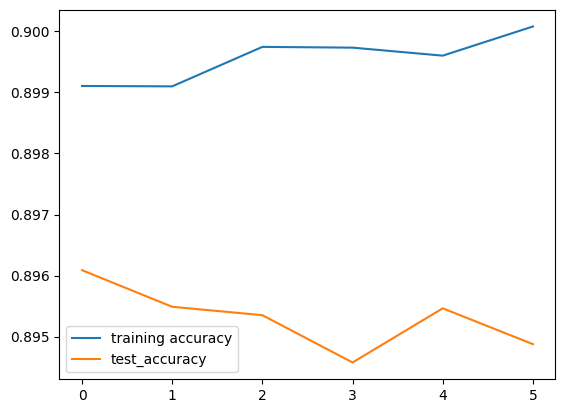

In [40]:
sns.lineplot(x=model.history.epoch,y=model.history.history['accuracy'],label='training accuracy')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_accuracy'],label='test_accuracy')

### Hyperparameter Tuning

In [ ]:
import optuna

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall


# Objective Function
def objective(trial):

    # Hyperparameters
    n_layers = trial.suggest_int("n_layers", 1, 4)
    learning_rate = trial.suggest_float("learning_rate",1e-4,1e-2,log=True)
    batch_size = trial.suggest_categorical("batch_size",[64, 128, 256, 512])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])

    optimizer_name = trial.suggest_categorical("optimizer",["Adam", "RMSprop", "SGD"])


    # Model
    model = Sequential()

    model.add(Input(shape=(Xtrain.shape[1],)))

    # Hidden Layers
    for i in range(n_layers):

        units = trial.suggest_categorical(f"units_{i}",[16, 32, 64, 128, 256])
        dropout_rate = trial.suggest_float(f"dropout_{i}",0.1,0.5)

        regularization = trial.suggest_float(f"regularization_{i}",1e-5,1e-2,log=True)

        model.add(Dense(units,activation=activation,kernel_regularizer=L1L2(l1=regularization,l2=regularization)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    # Output Layer
    model.add(Dense(1, activation="sigmoid"))

    # Optimizer
    if optimizer_name == "Adam":
        optimizer = Adam(learning_rate=learning_rate)

    elif optimizer_name == "RMSprop":
        optimizer = RMSprop(learning_rate=learning_rate)

    else:
        optimizer = SGD(learning_rate=learning_rate)

    # Compile
    model.compile(optimizer=optimizer,loss="binary_crossentropy",metrics=["accuracy", Precision(name="precision"),Recall(name="recall")])

    # Early Stopping
    early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

    # Train
    history = model.fit(Xtrain,ytrain,validation_split=0.2,epochs=50,batch_size=batch_size,class_weight=dict_class,callbacks=[early_stop])

    # Return Best Validation Accuracy
    return max(history.history["val_accuracy"])


# Create Study
study = optuna.create_study(direction="maximize")

# Start Optimization
study.optimize(objective, n_trials=10)


[I 2026-07-30 15:26:54,394] A new study created in memory with name: no-name-e5d2129e-9081-4d04-96ed-9ea256050f9e


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6726 - loss: 0.5786 - precision: 0.9547 - recall: 0.6602 - val_accuracy: 0.7574 - val_loss: 0.5094 - val_precision: 0.9705 - val_recall: 0.7475
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7558 - loss: 0.4961 - precision: 0.9628 - recall: 0.7522 - val_accuracy: 0.7721 - val_loss: 0.4824 - val_precision: 0.9689 - val_recall: 0.7661
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7701 - loss: 0.4830 - precision: 0.9639 - recall: 0.7682 - val_accuracy: 0.7763 - val_loss: 0.4697 - val_precision: 0.9687 - val_recall: 0.7711
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7719 - loss: 0.4752 - precision: 0.9650 - recall: 0.7693 - val_accuracy: 0.7759 - val_loss: 0.4665 - val_precision: 0.9691 - val_recall: 0.7704
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7748 - loss: 0.4712 - precision: 0.9656 - recall: 0.7722 - val_accuracy: 0.7725 - va

[I 2026-07-30 15:27:54,819] Trial 0 finished with value: 0.7762500047683716 and parameters: {'n_layers': 1, 'learning_rate': 0.008535670353246207, 'batch_size': 256, 'activation': 'relu', 'optimizer': 'SGD', 'units_0': 32, 'dropout_0': 0.49487327514321167, 'regularization_0': 6.801498477708825e-05}. Best is trial 0 with value: 0.7762500047683716.


Epoch 1/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.7521 - loss: 0.6333 - precision: 0.9653 - recall: 0.7458 - val_accuracy: 0.7685 - val_loss: 0.5085 - val_precision: 0.9696 - val_recall: 0.7613
Epoch 2/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7678 - loss: 0.5113 - precision: 0.9677 - recall: 0.7621 - val_accuracy: 0.7837 - val_loss: 0.5355 - val_precision: 0.9671 - val_recall: 0.7813
Epoch 3/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7679 - loss: 0.5076 - precision: 0.9675 - recall: 0.7625 - val_accuracy: 0.7573 - val_loss: 0.5150 - val_precision: 0.9716 - val_recall: 0.7465
Epoch 4/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7656 - loss: 0.5061 - precision: 0.9682 - recall: 0.7592 - val_accuracy: 0.7486 - val_loss: 0.5266 - val_precision: 0.9732 - val_recall: 0.7351
Epoch 5/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7651 - loss: 0.5100 - precision: 0.9681 - recall: 0.7587 - val_accuracy: 0.7594

[I 2026-07-30 15:29:27,077] Trial 1 finished with value: 0.7837374806404114 and parameters: {'n_layers': 2, 'learning_rate': 0.0005810086818044205, 'batch_size': 64, 'activation': 'relu', 'optimizer': 'RMSprop', 'units_0': 256, 'dropout_0': 0.3831534332129264, 'regularization_0': 5.0604954781300854e-05, 'units_1': 256, 'dropout_1': 0.43416868347301996, 'regularization_1': 7.318867894094518e-05}. Best is trial 1 with value: 0.7837374806404114.


...

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5823 - loss: 1.0837 - precision: 0.9518 - recall: 0.5545 - val_accuracy: 0.6355 - val_loss: 1.1165 - val_precision: 0.9846 - val_recall: 0.5959
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6438 - loss: 0.9679 - precision: 0.9773 - recall: 0.6104 - val_accuracy: 0.6655 - val_loss: 1.0810 - val_precision: 0.9830 - val_recall: 0.6316
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6689 - loss: 0.9507 - precision: 0.9759 - recall: 0.6404 - val_accuracy: 0.6898 - val_loss: 1.0459 - val_precision: 0.9809 - val_recall: 0.6610
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6881 - loss: 0.9371 - precision: 0.9749 - recall: 0.6634 - val_accuracy: 0.7048 - val_loss: 1.0199 - val_precision: 0.9795 - val_recall: 0.6794
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7026 - loss: 0.9276 - precision: 0.9732 - recall: 0.6816 - val_accuracy: 0.7179 - va

[I 2026-07-30 15:47:21,230] Trial 7 finished with value: 0.7787125110626221 and parameters: {'n_layers': 1, 'learning_rate': 0.0003929621577417365, 'batch_size': 256, 'activation': 'tanh', 'optimizer': 'SGD', 'units_0': 256, 'dropout_0': 0.1519457371963311, 'regularization_0': 0.0008365460820584105}. Best is trial 2 with value: 0.8112000226974487.


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6047 - loss: 0.6851 - precision: 0.9460 - recall: 0.5852 - val_accuracy: 0.6653 - val_loss: 0.6910 - val_precision: 0.9651 - val_recall: 0.6437
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6703 - loss: 0.6165 - precision: 0.9577 - recall: 0.6551 - val_accuracy: 0.7066 - val_loss: 0.6399 - val_precision: 0.9667 - val_recall: 0.6910
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7016 - loss: 0.5902 - precision: 0.9595 - recall: 0.6909 - val_accuracy: 0.7285 - val_loss: 0.6101 - val_precision: 0.9679 - val_recall: 0.7157
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7212 - loss: 0.5731 - precision: 0.9611 - recall: 0.7128 - val_accuracy: 0.7401 - val_loss: 0.5903 - val_precision: 0.9684 - val_recall: 0.7290
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7327 - loss: 0.5606 - precision: 0.9619 - recall: 0.7257 - val_accuracy: 0.7504 - va

[I 2026-07-30 15:49:55,330] Trial 8 finished with value: 0.7629250288009644 and parameters: {'n_layers': 2, 'learning_rate': 0.0011523682279568782, 'batch_size': 256, 'activation': 'relu', 'optimizer': 'SGD', 'units_0': 16, 'dropout_0': 0.14179128985829817, 'regularization_0': 0.00041294846271187566, 'units_1': 128, 'dropout_1': 0.1368669025827335, 'regularization_1': 6.254582935942333e-05}. Best is trial 2 with value: 0.8112000226974487.


Epoch 1/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7248 - loss: 0.5048 - precision: 0.9639 - recall: 0.7147 - val_accuracy: 0.7667 - val_loss: 0.4792 - val_precision: 0.9709 - val_recall: 0.7581
Epoch 2/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7673 - loss: 0.4617 - precision: 0.9666 - recall: 0.7626 - val_accuracy: 0.7727 - val_loss: 0.4683 - val_precision: 0.9703 - val_recall: 0.7655
Epoch 3/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7731 - loss: 0.4565 - precision: 0.9669 - recall: 0.7690 - val_accuracy: 0.7703 - val_loss: 0.4701 - val_precision: 0.9709 - val_recall: 0.7623
Epoch 4/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7743 - loss: 0.4541 - precision: 0.9670 - recall: 0.7704 - val_accuracy: 0.7712 - val_loss: 0.4673 - val_precision: 0.9703 - val_recall: 0.7639
Epoch 5/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7746 - loss: 0.4526 - precision: 0.9674 - recall: 0.7705 - val_accuracy: 0.7728

In [53]:
# Best Trial
print("Best Validation Accuracy :", study.best_value)

print("\nBest Hyperparameters:\n")

for key, value in study.best_params.items():
    print(f"{key} : {value}")

Best Validation Accuracy : 0.8112000226974487

Best Hyperparameters:

n_layers : 3
learning_rate : 0.002589051569821834
batch_size : 64
activation : tanh
optimizer : RMSprop
units_0 : 256
dropout_0 : 0.32249158778234854
regularization_0 : 1.7733264569678538e-05
units_1 : 64
dropout_1 : 0.1350107697754399
regularization_1 : 0.003884361395546827
units_2 : 16
dropout_2 : 0.3472068798420902
regularization_2 : 0.0006567032173762252


In [58]:
# Build Model
model = Sequential()

# Input Layer
model.add(Input(shape=(Xtrain.shape[1],)))

# Hidden Layer 1
model.add(Dense(
    256,
    activation='tanh',
    kernel_regularizer=L1L2(  
        l1=1.7733264569678538e-05,
        l2=1.7733264569678538e-05
    )
))
model.add(Dropout(0.32249158778234854))

# Hidden Layer 2
model.add(Dense(
    64,
    activation='tanh',
    kernel_regularizer=L1L2(
        l1=0.003884361395546827,
        l2=0.003884361395546827
    )
))
model.add(Dropout(0.1350107697754399))

# Hidden Layer 3
model.add(Dense(
    16,
    activation='tanh',
    kernel_regularizer=L1L2(
        l1=0.0006567032173762252,
        l2=0.0006567032173762252
    )
))
model.add(Dropout(0.3472068798420902))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
optimizer = RMSprop(learning_rate=0.002589051569821834)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    Xtrain,
    ytrain,
    validation_data=(Xtest, ytest),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    class_weight=dict_class,
    verbose=1
)

Epoch 1/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - Precision: 0.9668 - Recall: 0.7741 - accuracy: 0.7772 - loss: 0.6084 - val_Precision: 0.9675 - val_Recall: 0.7760 - val_accuracy: 0.7796 - val_loss: 0.5709
Epoch 2/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - Precision: 0.9668 - Recall: 0.7748 - accuracy: 0.7780 - loss: 0.5861 - val_Precision: 0.9630 - val_Recall: 0.8066 - val_accuracy: 0.8023 - val_loss: 0.5285
Epoch 3/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - Precision: 0.9672 - Recall: 0.7722 - accuracy: 0.7759 - loss: 0.5875 - val_Precision: 0.9698 - val_Recall: 0.7614 - val_accuracy: 0.7689 - val_loss: 0.5911
Epoch 4/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - Precision: 0.9672 - Recall: 0.7730 - accuracy: 0.7767 - loss: 0.5878 - val_Precision: 0.9666 - val_Recall: 0.7838 - val_accuracy: 0.7857 - val_loss: 0.5516
Epoch 5/50
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - Precision: 0.9673 - Recall: 0.7718 - accuracy: 0.7757 - loss: 0.5873 - val_Precision: 0.968

<Axes: >

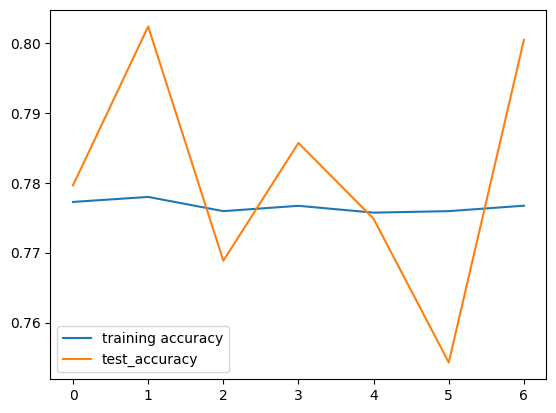

In [59]:
sns.lineplot(x=model.history.epoch,y=model.history.history['accuracy'],label='training accuracy')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_accuracy'],label='test_accuracy')

### Model Evaluvation

In [60]:
loss, accuracy, precision, recall = model.evaluate(Xtest, ytest)

print("Loss      :", loss)
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - Precision: 0.9630 - Recall: 0.8066 - accuracy: 0.8023 - loss: 0.5285
Loss      : 0.5285013914108276
Accuracy  : 0.8023200035095215
Precision : 0.9630337357521057
Recall    : 0.806603193283081


In [61]:
import numpy as np
ypred=np.where(model.predict(Xtest)>0.5,1,0)

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [62]:
print(classification_report(ypred,ytest))

              precision    recall  f1-score   support

           0       0.77      0.35      0.48     26203
           1       0.81      0.96      0.88     73797

    accuracy                           0.80    100000
   macro avg       0.79      0.66      0.68    100000
weighted avg       0.80      0.80      0.77    100000



In [63]:
import pickle
with open('/kaggle/working/preprocessor.pkl','wb') as f:
    pickle.dump(preprocessor,f)

In [64]:
model.save('/kaggle/working/architecture.keras')


In [65]:
from keras.models import load_model

deployment=load_model('/kaggle/working/architecture.keras')

In [66]:
import pandas as pd

data = pd.DataFrame({
    'age': [18],
    'gender': ['Female'],
    'state': ['California'],
    'family_income': [85000],
    'high_school_gpa': [3.85],
    'sat_score': [1420],
    'act_score': [31],
    'attendance_rate': [96],
    'ap_courses': [5],
    'extracurricular_count': [4],
    'volunteer_hours': [180],
    'leadership_positions': [2],
    'coding_projects': [8],
    'social_media_hours': [2.5],
    'online_certifications': [6],
    'essay_score': [92],
    'recommendation_score': [90],
    'interview_score': [88]
})

In [67]:
# Transform the input
data_preprocessed = preprocessor.transform(data)

# Predict probability
probability = model.predict(data_preprocessed)

print("Admission Probability:", probability[0][0])

# Convert probability into class
prediction = (probability > 0.5).astype(int)

if prediction[0][0] == 1:
    print("Student is likely to be Admitted.")
else:
    print("Student is likely to be Rejected.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Admission Probability: 0.9675511
Student is likely to be Admitted.


In [6]:
import sklearn
print(sklearn.__version__)

1.6.1


## Conclusion 

Developed an Artificial Neural Network (ANN) to predict college admission status. 
Performed data preprocessing and hyperparameter tuning. 
Achieved a Best Validation Accuracy of 81.12%. 
Successfully deployed the model using Streamlit for real-time predictions. 
The solution supports faster, consistent, and data-driven admission decisions while reducing manual effort.

